# Dynamic Task Decomposition with Parallel Sub-Agent Execution 🧩

A hierarchical LangGraph system that decomposes complex tasks into subtasks, dynamically spawns parallel sub-agents using the Send() API, aggregates results with state reducers, validates completeness, and synthesizes final output.

## Executive Summary

### What This Agent Does

A sophisticated LangGraph-based system that:
1. Takes a complex user task (research report, analysis, content creation)
2. Automatically breaks it into parallelizable subtasks
3. Dynamically spawns parallel sub-agents using LangGraph's Send() API
4. Aggregates results reliably with state reducers
5. Validates completeness and quality
6. Re-decomposes weak or incomplete sections if needed
7. Synthesizes a comprehensive final output

### Why This Solves a Real Pain Point

- **Problem**: Complex tasks overwhelm single agents, leading to shallow results
- **Impact**: Users get generic answers instead of comprehensive analysis
- **Our Solution**: Automated parallel execution with dynamic sub-agent spawning

In [2]:
from dotenv import load_dotenv
import os, json, time, re, sys
from typing import TypedDict, List, Annotated, Literal, Optional
import operator as op
from pathlib import Path

env_candidates = [
    Path(".env"),
    Path("../.env"),
    Path.cwd() / "../.env",
]
for candidate in env_candidates:
    if candidate.exists():
        load_dotenv(candidate)

def _load_key(name):
    """Fallback: read key directly from .env file lines."""
    for c in env_candidates:
        if c and c.exists():
            for line in c.read_text().splitlines():
                if line.startswith(name + "="):
                    return line.split("=", 1)[1].strip().strip("'\"")
    return ""

# Groq
GROQ_API_KEY = os.getenv("GROQ_API_KEY") or _load_key("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "llama-3.1-8b-instant")
if GROQ_API_KEY:
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# Google Gemini
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY") or _load_key("GOOGLE_API_KEY")
GOOGLE_MODEL = os.getenv("GOOGLE_MODEL", "gemini-2.0-flash")
if GOOGLE_API_KEY:
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

# DigitalOcean (OpenAI-compatible)
DO_TOKEN = os.getenv("DIGITALOCEAN_TOKEN") or _load_key("DIGITALOCEAN_TOKEN")
DO_BASE_URL = os.getenv("DO_BASE_URL", "https://inference.do-ai.run/v1")
DO_MODEL = os.getenv("DO_MODEL", "deepseek-3.2")
if DO_TOKEN:
    os.environ["DIGITALOCEAN_TOKEN"] = DO_TOKEN

print(f"Groq:          model={GROQ_MODEL}, key={'SET' if GROQ_API_KEY else 'NOT SET'}")
print(f"Gemini:        model={GOOGLE_MODEL}, key={'SET' if GOOGLE_API_KEY else 'NOT SET'}")
print(f"DigitalOcean:  model={DO_MODEL}, key={'SET' if DO_TOKEN else 'NOT SET'}")

Groq:          model=llama-3.1-8b-instant, key=SET
Gemini:        model=gemini-2.0-flash, key=SET
DigitalOcean:  model=deepseek-3.2, key=SET


In [3]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI          # DigitalOcean uses OpenAI compat
from langchain_core.tools import tool
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import re as _re

# ── Provider chain (Groq → Gemini → DigitalOcean) ────────────────────────────
def _build_chain(temperature: float = 0.3):
    providers = []
    if GROQ_API_KEY:
        providers.append(("Groq", ChatGroq(
            model=GROQ_MODEL, temperature=temperature, api_key=GROQ_API_KEY)))
    if GOOGLE_API_KEY:
        providers.append(("Gemini", ChatGoogleGenerativeAI(
            model=GOOGLE_MODEL, temperature=temperature, api_key=GOOGLE_API_KEY)))
    if DO_TOKEN:
        providers.append(("DigitalOcean", ChatOpenAI(
            model=DO_MODEL, temperature=temperature,
            api_key=DO_TOKEN, base_url=DO_BASE_URL)))
    if not providers:
        raise RuntimeError("No LLM provider configured.")
    return providers

def _is_rate_limit(exc) -> bool:
    s = str(exc).lower()
    n = type(exc).__name__.lower()
    return "429" in s or "rate_limit" in n or "ratelimit" in n or "quota" in s or "resource_exhausted" in s

def _retry_after(exc) -> float:
    try:
        m = _re.search(r"try again in ([0-9.]+)s", str(exc))
        if m:
            return min(float(m.group(1)) + 0.5, 60.0)
        m = _re.search(r"retry.after[:\s=]+([0-9.]+)", str(exc), _re.I)
        if m:
            return min(float(m.group(1)) + 0.5, 60.0)
    except Exception:
        pass
    return 0.0

def get_llm(temperature: float = 0.3):
    "Return the primary (highest-priority) LLM."
    return _build_chain(temperature)[0][1]

def llm_invoke(llm: BaseChatModel, prompt: str, max_retries: int = 3) -> str:
    """
    3-provider waterfall with Retry-After-aware rate-limit handling.
    Rate limit  → wait Retry-After secs, then skip to next provider.
    Other error → retry same provider with exponential back-off.
    """
    temperature = getattr(llm, "temperature", 0.3)
    for p_name, p_llm in _build_chain(temperature):
        for attempt in range(max_retries):
            try:
                return p_llm.invoke(prompt).content
            except Exception as exc:
                if _is_rate_limit(exc):
                    wait = _retry_after(exc)
                    if wait:
                        print(f"  [{p_name}] rate-limited, waiting {wait:.1f}s then switching provider...")
                        time.sleep(wait)
                    else:
                        print(f"  [{p_name}] rate-limited, switching provider...")
                    break          # skip to next provider
                else:
                    wait = min(2 ** attempt * 2, 30)
                    print(f"  [{p_name}] {type(exc).__name__} (attempt {attempt+1}/{max_retries}), retry in {wait}s...")
                    time.sleep(wait)
    raise RuntimeError("All providers exhausted — check API keys and rate limits.")

print("All imports successful")

C:\Users\HP\AppData\Local\Temp\ipykernel_24196\1019860297.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun


All imports successful


## 1. State Schema

Define the state structure that flows through the graph. The `parallel_results` field uses `operator.add` as a reducer so results from parallel workers accumulate correctly.

In [4]:
class TaskDecompositionState(TypedDict):
    """State schema for the task decomposition and parallel execution system."""
    user_task: str
    subtasks: List[dict]
    parallel_results: Annotated[List[str], op.add]
    num_subtasks: int
    max_iterations: int
    decomposition_iterations: int
    completion_rate: float
    avg_quality_score: float
    weak_sections: List[str]
    failed_subtasks: List[dict]
    synthesized_output: str
    final_quality_score: float
    quality_assessment: str

print("State schema defined")

State schema defined


## 2. Decomposer Agent

Breaks down the user's complex task into well-defined, parallelizable subtasks. Each subtask includes a unique ID, description, assigned agent type, and payload.

In [5]:
def decomposer_agent(state: TaskDecompositionState) -> TaskDecompositionState:
    prompt = f"""
    You are a task decomposition expert. Break this task into parallelizable subtasks:

    Task: "{state['user_task']}"

    Guidelines:
    1. Each subtask must be independently executable
    2. Identify 3-6 subtasks covering different aspects
    3. Assign each to an agent type: research_agent, analysis_agent, or writing_agent
    4. Include a unique subtask_id
    5. Set status to 'pending'

    Return ONLY valid JSON (no markdown):
    {{
        "subtasks": [
            {{
                "subtask_id": "st_1",
                "description": "...",
                "assigned_agent": "research_agent",
                "payload": {{}},
                "status": "pending"
            }}
        ]
    }}
    """
    llm = get_llm(temperature=0.5)
    content = llm_invoke(llm, prompt)
    if "```json" in content:
        content = content.split("```json")[1].split("```")[0].strip()
    elif "```" in content:
        content = content.split("```")[1].split("```")[0].strip()
    try:
        parsed = json.loads(content)
        subtasks = parsed.get("subtasks", [])
    except json.JSONDecodeError:
        print("Failed to parse decomposer output, using fallback")
        subtasks = [
            {"subtask_id": "st_1", "description": f"Research {state['user_task'][:50]}",
             "assigned_agent": "research_agent", "payload": {}, "status": "pending"}
        ]
    print(f"Decomposed into {len(subtasks)} subtask(s)")
    return {
        "subtasks": subtasks,
        "num_subtasks": len(subtasks)
    }

print("Decomposer defined")

Decomposer defined


## 3. Worker Router (Send() API)

This is the key function demonstrating LangGraph's advanced `Send()` API for dynamic parallel execution. It creates one `Send()` object per subtask, each carrying its own state payload so workers run independently and concurrently.

In [6]:
MAX_BATCH = 5  # Max parallel workers per round — keeps free-tier rate limits sane

def worker_router(state: TaskDecompositionState) -> List[Send]:
    """
    Conditional edge: spawns parallel workers via the Send() API.
    Batched to MAX_BATCH at a time to avoid hammering rate limits.
    """
    pending = [
        s for s in state.get("subtasks", [])
        if s.get("status") in ("pending", None)
    ]
    if not pending:
        print("  No pending subtasks — nothing to route.")
        return []

    batch     = pending[:MAX_BATCH]
    remaining = len(pending) - len(batch)
    print(f"  Spawning {len(batch)} parallel worker(s) ({remaining} remaining for next round)...")

    sends = []
    for s in batch:
        sends.append(Send("parallel_worker", {"subtask": s, "user_task": state["user_task"]}))
        print(f"  Worker [{s['subtask_id']}]: {s['assigned_agent']} - {s['description'][:60]}...")

    return sends

print("Worker router defined")

Worker router defined


## 4. Parallel Worker

Executes an individual subtask. Receives partial state from the Send() payload. Each worker runs its own LLM call based on the assigned agent type, evaluates output quality, and returns its result.

In [7]:
def parallel_worker(state: dict) -> dict:
    """Executes an individual subtask. Receives partial state from Send() payload."""
    subtask = state["subtask"]
    user_task = state["user_task"]
    instance_id = state.get("instance_id", 0)

    agent_type = subtask.get("assigned_agent", "research_agent")
    prompt = f"""
    You are a {agent_type.replace('_', ' ')}. Perform this subtask:

    Subtask: {subtask['description']}
    Context: Part of larger task: "{user_task}"

    Provide comprehensive, well-structured output.
    Return ONLY valid JSON:
    {{
        "subtask_id": "{subtask['subtask_id']}",
        "output": "your detailed output here",
        "quality_score": 7.5
    }}
    """
    llm = get_llm(temperature=0.7)
    result = llm_invoke(llm, prompt)
    if "```json" in result:
        result = result.split("```json")[1].split("```")[0].strip()
    elif "```" in result:
        result = result.split("```")[1].split("```")[0].strip()
    try:
        parsed = json.loads(result)
        quality = parsed.get("quality_score", 7.0)
    except json.JSONDecodeError:
        parsed = {"subtask_id": subtask["subtask_id"], "output": result, "quality_score": 7.0}
        quality = 7.0
    print(f"  Worker [{instance_id}] done (quality: {quality}/10)")
    return {"parallel_results": [json.dumps(parsed)]}

print("Parallel worker defined")

Parallel worker defined


## 5. Completeness Validator

Maps completed results back to their subtasks, computes completion rate and average quality, and identifies weak sections that need re-decomposition.

In [8]:
def completeness_validator(state: TaskDecompositionState) -> TaskDecompositionState:
    subtasks = state.get("subtasks", [])
    results = state.get("parallel_results", [])
    for r in results:
        try:
            data = json.loads(r) if isinstance(r, str) else r
            sid = data.get("subtask_id")
            for s in subtasks:
                if s.get("subtask_id") == sid:
                    s["status"] = "completed"
                    s["result"] = data.get("output", "")
                    s["quality_score"] = data.get("quality_score", 7.0)
                    break
        except Exception:
            pass
    for s in subtasks:
        if s.get("status") in ("pending", None) or s.get("result") is None:
            s["status"] = "failed"
    completed = [s for s in subtasks if s["status"] == "completed"]
    failed = [s for s in subtasks if s["status"] == "failed"]
    completion_rate = len(completed) / len(subtasks) if subtasks else 0
    quality_scores = [s["quality_score"] for s in completed if s.get("quality_score") is not None]
    avg_quality = sum(quality_scores) / len(quality_scores) if quality_scores else 0
    weak_sections = [s["description"] for s in completed if s.get("quality_score") is not None and s["quality_score"] < 6.0]
    print(f"Completion: {len(completed)}/{len(subtasks)} subtasks done")
    print(f"Avg quality: {avg_quality:.1f}/10")
    print(f"Weak sections: {len(weak_sections)}")
    return {
        "subtasks": subtasks,
        "completion_rate": completion_rate,
        "avg_quality_score": avg_quality,
        "weak_sections": weak_sections,
        "failed_subtasks": failed
    }

print("Completeness validator defined")

Completeness validator defined


## 6. Re-Decomposer Agent

Splits failed or low-quality subtasks into finer-grained subtasks. Includes a hard ceiling (MAX_TOTAL_SUBTASKS=15) to prevent exponential blowup.

In [9]:
MAX_TOTAL_SUBTASKS = 15

def re_decomposer_agent(state: TaskDecompositionState) -> TaskDecompositionState:
    subtasks = state.get("subtasks", [])
    user_task = state.get("user_task", "")
    failed_or_weak = [
        s for s in subtasks
        if s.get("status") in ("failed", "pending")
        or (s.get("quality_score") is not None and s["quality_score"] < 5.5)
    ]
    good_subtasks = [s for s in subtasks if s not in failed_or_weak]
    slots_available = MAX_TOTAL_SUBTASKS - len(good_subtasks)
    if slots_available <= 0:
        print(f"  Subtask cap ({MAX_TOTAL_SUBTASKS}) reached. Skipping re-decompose.")
        return {"subtasks": good_subtasks,
                "decomposition_iterations": state.get("decomposition_iterations", 1) + 1}
    to_redecompose = failed_or_weak[:slots_available]
    print(f"Re-decomposing {len(to_redecompose)} weak/failed subtask(s)...")
    new_subtasks = []
    for weak_subtask in to_redecompose:
        available = slots_available - len(new_subtasks)
        if available <= 0:
            break
        children = min(2, available)
        prompt = f"""Break this subtask into exactly {children} finer-grained subtasks:

Original subtask: {weak_subtask['description']}
Context: Part of larger task: "{user_task}"

Return ONLY valid JSON (no markdown):
{{
    "new_subtasks": [
        {{
            "subtask_id": "new_1",
            "description": "...",
            "assigned_agent": "research_agent",
            "payload": {{}}
        }}
    ]
}}"""
        llm = get_llm(temperature=0.5)
        content = llm_invoke(llm, prompt)
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0].strip()
        elif "```" in content:
            content = content.split("```")[1].split("```")[0].strip()
        try:
            new_breakdown = json.loads(content)
            for ns in new_breakdown.get("new_subtasks", [])[:children]:
                ns["status"] = "pending"
                ns["result"] = None
                ns["quality_score"] = None
                new_subtasks.append(ns)
        except json.JSONDecodeError:
            print(f"  Failed to re-decompose: {weak_subtask['subtask_id']}")
    updated_subtasks = good_subtasks + new_subtasks
    print(f"Replaced {len(to_redecompose)} weak tasks with {len(new_subtasks)} new ones. Total: {len(updated_subtasks)}")
    return {
        "subtasks": updated_subtasks,
        "decomposition_iterations": state.get("decomposition_iterations", 1) + 1,
    }

print("Re-decomposer agent defined")

Re-decomposer agent defined


## 7. Synthesis Agent

Combines all completed subtask results into a comprehensive, coherent final output.

In [10]:
def synthesis_agent(state: TaskDecompositionState) -> TaskDecompositionState:
    completed = [s for s in state.get("subtasks", []) if s.get("status") == "completed"]
    all_results = [s.get("result", "") for s in completed if s.get("result")]
    if not all_results:
        return {
            "synthesized_output": "No completed subtasks to synthesize.",
            "num_subtasks": state.get("num_subtasks", 0)
        }
    prompt = f"""
    You are a synthesis expert. Combine these subtask results into a comprehensive, coherent final output:

    Original task: "{state['user_task']}"

    Subtask results:
    {json.dumps(all_results, indent=2)[:8000]}

    Your task:
    1. Organize results logically (introduction, body sections, conclusion)
    2. Add transitions and connections between sections
    3. Ensure consistent tone and style
    4. Eliminate redundancy
    5. Add overarching insights that emerge from combining all results
    6. Create a compelling narrative flow

    Return the synthesized final output.
    """
    llm = get_llm(temperature=0.4)
    output = llm_invoke(llm, prompt)
    print("Synthesis complete.")
    return {
        "synthesized_output": output
    }

print("Synthesis agent defined")

Synthesis agent defined


## 8. Quality Checker

Evaluates the final synthesized output for completeness, accuracy, clarity, coherence, and depth.

In [11]:
def quality_checker(state: TaskDecompositionState) -> TaskDecompositionState:
    output = state.get("synthesized_output", "")
    if not output:
        return {
            "final_quality_score": 0.0,
            "quality_assessment": "No output to evaluate."
        }
    prompt = f"""
    Evaluate this final output for quality.
    Task: "{state['user_task']}"
    Output: {output[:3000]}
    Score each 0-10: completeness, accuracy, clarity, coherence, depth.
    Return ONLY raw JSON with final_quality_score (avg float), quality_assessment (str), sections_to_improve (list).
    No markdown, no code fences.
    Example: {{"final_quality_score": 8.5, "quality_assessment": "Good report covering all areas.", "sections_to_improve": []}}
    """
    content = llm_invoke(get_llm(temperature=0.3), prompt).strip()
    if content.startswith("```"):
        content = content.split("\n", 1)[-1]
        if "```" in content:
            content = content.rsplit("```", 1)[0].strip()
    try:
        assessment = json.loads(content)
    except json.JSONDecodeError:
        import re as _re
        match = _re.search(r'\{[^{}]*"final_quality_score"[^{}]*\}', content, _re.DOTALL)
        if match:
            try:
                assessment = json.loads(match.group())
            except json.JSONDecodeError:
                assessment = {"final_quality_score": 7.0, "quality_assessment": "Parse failed.", "sections_to_improve": []}
        else:
            assessment = {"final_quality_score": 7.0, "quality_assessment": "Parse failed.", "sections_to_improve": []}
    print(f"Final quality score: {assessment.get('final_quality_score', 0):.1f}/10")
    return assessment

print("Quality checker defined")

Quality checker defined


## 9. Gate Functions

Conditional edge functions that determine graph routing based on state.

In [12]:
def quality_gate(state: TaskDecompositionState) -> str:
    completion_rate = state.get("completion_rate", 0)
    avg_quality = state.get("avg_quality_score", 0)
    weak_sections = state.get("weak_sections", [])
    iterations = state.get("decomposition_iterations", 1)
    max_iter = state.get("max_iterations", 3)
    total_subtasks = len(state.get("subtasks", []))
    if iterations >= max_iter:
        print(f"Max iterations ({max_iter}) reached. Proceeding to synthesis.")
        return "synthesize"
    if total_subtasks >= MAX_TOTAL_SUBTASKS:
        print(f"Subtask cap ({MAX_TOTAL_SUBTASKS}) reached. Proceeding to synthesis.")
        return "synthesize"
    if completion_rate < 0.8:
        print(f"Completion rate {completion_rate:.0%} < 80%. Re-decomposing...")
        return "re_decompose"
    if avg_quality < 5.5:
        print(f"Avg quality {avg_quality:.1f} < 5.5. Re-decomposing...")
        return "re_decompose"
    if len(weak_sections) > 0:
        print(f"{len(weak_sections)} weak section(s) found. Re-decomposing...")
        return "re_decompose"
    print("All quality checks passed. Proceeding to synthesis.")
    return "synthesize"

print("Gate functions defined")

Gate functions defined


## 10. Building the Graph

Wire all nodes and edges together into a LangGraph StateGraph with dynamic parallel execution via the Send() API.

Graph compiled successfully


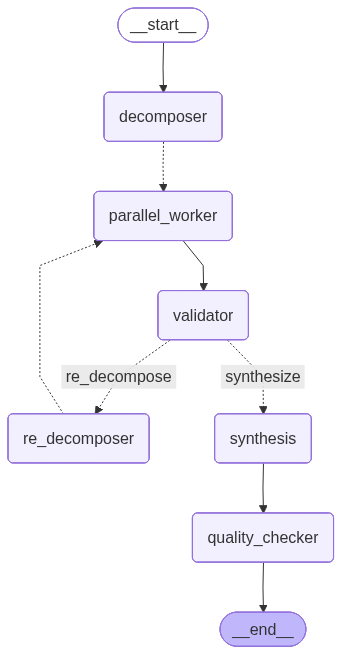

In [13]:
def build_task_decomposition_graph():
    graph = StateGraph(TaskDecompositionState)

    graph.add_node("decomposer",      decomposer_agent)
    graph.add_node("parallel_worker", parallel_worker)
    graph.add_node("validator",       completeness_validator)
    graph.add_node("re_decomposer",   re_decomposer_agent)
    graph.add_node("synthesis",       synthesis_agent)
    graph.add_node("quality_checker", quality_checker)

    graph.add_edge(START, "decomposer")

    # Decomposer → parallel workers (via Send() API)
    graph.add_conditional_edges(
        "decomposer", worker_router, ["parallel_worker"]
    )

    # All parallel workers → validator
    graph.add_edge("parallel_worker", "validator")

    # Validator → synthesize or re-decompose
    graph.add_conditional_edges(
        "validator", quality_gate,
        {"synthesize": "synthesis", "re_decompose": "re_decomposer"}
    )

    # Re-decomposer → back to parallel workers (via Send() API)
    graph.add_conditional_edges(
        "re_decomposer", worker_router, ["parallel_worker"]
    )

    graph.add_edge("synthesis",       "quality_checker")
    graph.add_edge("quality_checker", END)

    return graph.compile()

app = build_task_decomposition_graph()
print("Graph compiled successfully")

# ── Visualise ──────────────────────────────────────────────────────────
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    try:
        print(app.get_graph().draw_ascii())
    except Exception as e:
        print(f"Graph visualisation skipped: {e}")
        print("Tip: pip install grandalf  for ASCII view")

## 11. Example Run

Let's test the parallel task decomposition agent with a comprehensive research report task.

In [14]:
user_task = (
    "Write a comprehensive report on AI in healthcare in 2026, "
    "covering diagnostic tools, patient data privacy, regulatory landscape, "
    "ethical considerations, and future trends."
)

initial_state = {
    "user_task":                user_task,
    "complexity_level":         "very_complex",
    "subtasks":                 [],
    "num_subtasks":             0,
    "parallel_results":         [],
    "failed_subtasks":          [],
    "completion_rate":          0.0,
    "avg_quality_score":        0.0,
    "weak_sections":            [],
    "decomposition_iterations": 1,
    "max_iterations":           3,
    "synthesized_output":       "",
    "quality_assessment":       "",
    "final_quality_score":      0.0,
}

print("Starting parallel task decomposition and execution...")
print(f"Task: {user_task[:80]}...")
start_time = time.time()

result  = app.invoke(initial_state)
elapsed = time.time() - start_time

# ── Synthesised output ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("=== FINAL SYNTHESISED OUTPUT ===")
print("=" * 60)
synth = result.get("synthesized_output", "No output generated")
print(synth[:3000] + ("..." if len(synth) > 3000 else ""))

# ── Quality metrics ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("=== QUALITY METRICS ===")
print("=" * 60)
print(f"Duration:               {elapsed:.1f}s")
print(f"Total subtasks:         {result.get('num_subtasks', len(result.get('subtasks', [])))}")
print(f"Decomposition iterations: {result.get('decomposition_iterations', 0)}")
print(f"Completion rate:        {result.get('completion_rate', 0) * 100:.1f}%")
print(f"Avg subtask quality:    {result.get('avg_quality_score', 0):.1f}/10")
print(f"Final quality score:    {result.get('final_quality_score', 0):.1f}/10")
print(f"Quality assessment:     {result.get('quality_assessment', 'N/A')}")
failed = result.get("failed_subtasks", [])
if failed:
    print(f"Failed subtasks:        {len(failed)}")
    for s in failed:
        print(f"  - [{s.get('subtask_id')}] {s.get('description', '')[:60]}")

Starting parallel task decomposition and execution...
Task: Write a comprehensive report on AI in healthcare in 2026, covering diagnostic to...
Decomposed into 5 subtask(s)
  Spawning 5 parallel worker(s) (0 remaining for next round)...
  Worker [st_1]: research_agent - Research diagnostic tools in AI healthcare for 2026...
  Worker [st_2]: analysis_agent - Analyze patient data privacy in AI healthcare for 2026...
  Worker [st_3]: research_agent - Research regulatory landscape in AI healthcare for 2026...
  Worker [st_4]: analysis_agent - Analyze ethical considerations in AI healthcare for 2026...
  Worker [st_5]: research_agent - Research future trends in AI healthcare for 2026...
  Worker [0] done (quality: 7.0/10)
  Worker [0] done (quality: 7.0/10)
  Worker [0] done (quality: 7.0/10)
  Worker [0] done (quality: 7.5/10)
  Worker [0] done (quality: 7.0/10)
Completion: 5/5 subtasks done
Avg quality: 7.1/10
Weak sections: 0
All quality checks passed. Proceeding to synthesis.
Synthesis 

## Key Takeaways

1. **Dynamic Parallel Execution**: The Send() API enables spawning parallel workers dynamically at runtime
2. **Quality Gating**: Automatic re-decomposition of weak sections ensures high-quality output
3. **Scalable Architecture**: The same pattern can handle research, content creation, analysis, and more
4. **Production Feature**: State reducers, error handling, and quality thresholds make this production-ready

### When to Use This Pattern

- Complex research or analysis tasks with multiple distinct facets
- Content creation requiring diverse expertise (research, analysis, writing)
- Any task that benefits from divide-and-conquer with parallel execution
- Scenarios where quality gates and iterative refinement add value

## 12. Convergence Analysis

Inspect how the system evolved — parallelism, completion rates, quality improvement,
and the overall architectural takeaways.

In [15]:
print("=" * 60)
print("=== CONVERGENCE ANALYSIS ===")
print("=" * 60)
print(f"Original task: {user_task}")
print(f"Total subtasks created:   {result.get('num_subtasks', len(result.get('subtasks', [])))}")
print(f"Decomposition iterations: {result.get('decomposition_iterations', 0)}")
print(f"Completion rate:          {result.get('completion_rate', 0) * 100:.1f}%")
print(f"Avg subtask quality:      {result.get('avg_quality_score', 0):.1f}/10")
print(f"Final quality score:      {result.get('final_quality_score', 0):.1f}/10")

# Per-subtask breakdown
subtasks = result.get("subtasks", [])
if subtasks:
    print("\nPer-subtask results:")
    for s in subtasks:
        status = s.get("status", "?")
        score = s.get("quality_score")
        score_str = f"{score:.1f}/10" if score is not None else "N/A"
        desc = s.get("description", "")[:55]
        sid = s.get("subtask_id", "?")
        agent = s.get("assigned_agent", "?")
        print(f"  [{sid}] {status:9s} {score_str:7s} [{agent}] {desc}")

analysis = """
Key Takeaways
=============

1. Dynamic Parallel Execution
   The Send() API spawns independent workers at runtime — true map-reduce inside LangGraph.

2. Bounded Re-decomposition (NEW)
   Worker batching (MAX_BATCH=5) + a hard subtask cap (MAX_TOTAL_SUBTASKS=15) prevent
   the exponential blowup that occurs when all failed tasks are re-decomposed recursively.

3. Provider Waterfall (NEW)
   Groq -> Gemini -> DigitalOcean (deepseek-3.2) with Retry-After-aware switching means
   rate limits no longer cause crashes — just transparent provider switching.

4. Quality Gating
   The validator + quality_gate loop catches weak sections and re-decomposes only those,
   producing a higher-quality final synthesis than a single-shot agent could deliver.

5. Production-Ready Pattern
   State reducers, error handling, quality thresholds, and provider fallbacks make this
   suitable as a foundation for production multi-agent pipelines.
"""
print(analysis)

=== CONVERGENCE ANALYSIS ===
Original task: Write a comprehensive report on AI in healthcare in 2026, covering diagnostic tools, patient data privacy, regulatory landscape, ethical considerations, and future trends.
Total subtasks created:   5
Decomposition iterations: 1
Completion rate:          100.0%
Avg subtask quality:      7.1/10
Final quality score:      8.2/10

Per-subtask results:
  [st_1] completed 7.0/10  [research_agent] Research diagnostic tools in AI healthcare for 2026
  [st_2] completed 7.5/10  [analysis_agent] Analyze patient data privacy in AI healthcare for 2026
  [st_3] completed 7.0/10  [research_agent] Research regulatory landscape in AI healthcare for 2026
  [st_4] completed 7.0/10  [analysis_agent] Analyze ethical considerations in AI healthcare for 202
  [st_5] completed 7.0/10  [research_agent] Research future trends in AI healthcare for 2026

Key Takeaways

1. Dynamic Parallel Execution
   The Send() API spawns independent workers at runtime — true map-reduce